
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [1]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [7]:
class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty, pow_type="leading_zeros"):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash
        self.pow_type = pow_type        # Proof-of-Work type

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce,
            "pow_type": self.pow_type
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        start = time.time()             # start time
        attempts = 0                    # count tries
        target_met = False

        # Max SHA256 hash value (2^256 - 1) for numeric threshold calculation
        max_hash_value = 2**256 - 1

        while not target_met:
            self.hash = self.compute_hash()  # calculate hash

            if self.pow_type == "leading_zeros":
                target = '0' * self.difficulty
                if self.hash.startswith(target):
                    target_met = True
            elif self.pow_type == "numeric_threshold":
                # Target value decreases exponentially with difficulty
                # Higher difficulty means smaller target_value
                # Using 16 as base because SHA256 is hex (16) based
                target_value = max_hash_value // (16**self.difficulty)
                if int(self.hash, 16) < target_value:
                    target_met = True
            elif self.pow_type == "pattern_matching":
                # Difficulty controls the length of the suffix pattern
                # e.g., difficulty=2 means hash must end with '00'
                target_pattern = '0' * self.difficulty
                if self.hash.endswith(target_pattern):
                    target_met = True
            else:
                raise ValueError(f"Unknown PoW type: {self.pow_type}")

            if not target_met:
                self.nonce += 1                  # try next nonce
                attempts += 1
        return time.time() - start, attempts  # mining duration + attempts

##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [8]:
class Blockchain:
    def __init__(self, difficulty=3, reward=10, pow_type="leading_zeros"):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.pow_type = pow_type       # Proof-of-Work type for the blockchain
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty,
            self.pow_type # Pass pow_type
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty, self.pow_type) # Pass pow_type
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string

## 🚀 Example: Create Blockchain and Add Transactions

In [4]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 18.331234455108643 seconds
Attempts: 1310547


In [5]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1773670850.4833386
 Hash        : 000009d69b2ff51ad20491a294ed9ff6803dd645a9ae1130213cb60ca7a68629
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 846161
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1773670859.3958004
 Hash        : 00000708953c303ec80e87e35603c9cb7040b4796fa967b0ed58ecb86ba4a11f
 Prev Hash   : 000009d69b2ff51ad20491a294ed9ff6803dd645a9ae1130213cb60ca7a68629
 Difficulty  : 5
 Nonce       : 1310547
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

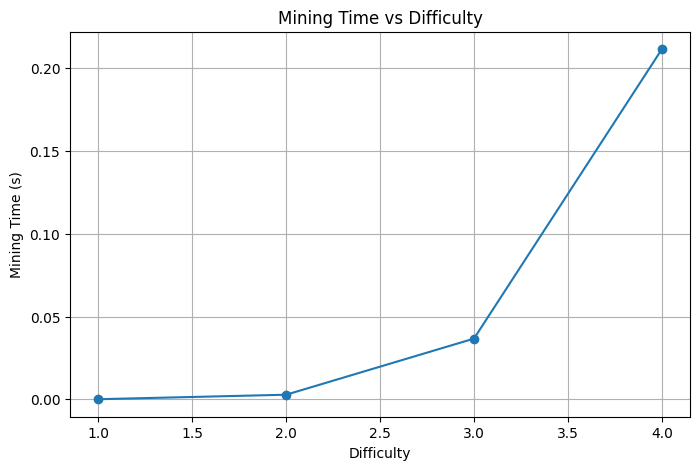

In [6]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


Testing Proof-of-Work type: leading_zeros
  Difficulty 1: Mining time = 0.0001 seconds (Attempts: 11)
  Difficulty 2: Mining time = 0.0018 seconds (Attempts: 164)
  Difficulty 3: Mining time = 0.0066 seconds (Attempts: 596)
  Difficulty 4: Mining time = 0.2937 seconds (Attempts: 13778)
Testing Proof-of-Work type: numeric_threshold
  Difficulty 1: Mining time = 0.0001 seconds (Attempts: 3)
  Difficulty 2: Mining time = 0.0083 seconds (Attempts: 387)
  Difficulty 3: Mining time = 0.2754 seconds (Attempts: 12171)
  Difficulty 4: Mining time = 0.1121 seconds (Attempts: 8600)
Testing Proof-of-Work type: pattern_matching
  Difficulty 1: Mining time = 0.0003 seconds (Attempts: 26)
  Difficulty 2: Mining time = 0.0004 seconds (Attempts: 38)
  Difficulty 3: Mining time = 0.0059 seconds (Attempts: 537)
  Difficulty 4: Mining time = 0.0945 seconds (Attempts: 8660)


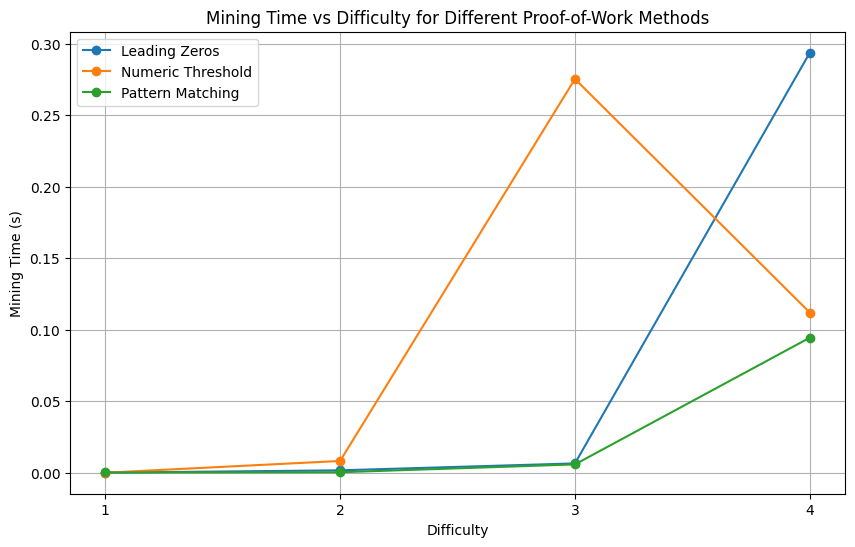

In [9]:
pow_types = ["leading_zeros", "numeric_threshold", "pattern_matching"]
difficulties = [1, 2, 3, 4] # Using the same difficulties as the previous example

mining_times_by_pow_type = {} # Dictionary to store mining times for each PoW type

for pow_type in pow_types:
    print(f"Testing Proof-of-Work type: {pow_type}")
    times_for_current_pow_type = []
    for d in difficulties:
        # Ensure difficulty is reasonable for each PoW type
        current_difficulty = d
        if pow_type == "numeric_threshold" and d > 6: # Numeric threshold becomes very hard quickly
            current_difficulty = 6
        elif pow_type == "pattern_matching" and d > 6: # Pattern matching can also be very hard
            current_difficulty = 6

        bc = Blockchain(difficulty=current_difficulty, reward=1, pow_type=pow_type) # New chain with specific PoW type
        bc.add_transaction("A", "B", 1) # Simple tx
        t, att = bc.mine_pending("MinerX") # Mine and time
        times_for_current_pow_type.append(t) # Record time
        print(f"  Difficulty {current_difficulty}: Mining time = {t:.4f} seconds (Attempts: {att})")
    mining_times_by_pow_type[pow_type] = times_for_current_pow_type

plt.figure(figsize=(10, 6))
for pow_type, times in mining_times_by_pow_type.items():
    plt.plot(difficulties[:len(times)], times, marker='o', label=f'{pow_type.replace("_", " ").title()}')

plt.xlabel('Difficulty')
plt.ylabel('Mining Time (s)')
plt.title('Mining Time vs Difficulty for Different Proof-of-Work Methods')
plt.xticks(difficulties)
plt.grid(True)
plt.legend()
plt.show()

Testing Proof-of-Work type: leading_zeros
  Difficulty 1: Mining time = 0.0000 seconds (Attempts: 0)
  Difficulty 2: Mining time = 0.0096 seconds (Attempts: 594)
  Difficulty 3: Mining time = 0.0134 seconds (Attempts: 1200)
  Difficulty 4: Mining time = 0.0004 seconds (Attempts: 32)
Testing Proof-of-Work type: numeric_threshold
  Difficulty 1: Mining time = 0.0007 seconds (Attempts: 60)
  Difficulty 2: Mining time = 0.0003 seconds (Attempts: 25)
  Difficulty 3: Mining time = 0.0039 seconds (Attempts: 337)
  Difficulty 4: Mining time = 0.3700 seconds (Attempts: 30600)
Testing Proof-of-Work type: pattern_matching
  Difficulty 1: Mining time = 0.0001 seconds (Attempts: 8)
  Difficulty 2: Mining time = 0.0053 seconds (Attempts: 489)
  Difficulty 3: Mining time = 0.0206 seconds (Attempts: 1878)
  Difficulty 4: Mining time = 1.5219 seconds (Attempts: 135615)


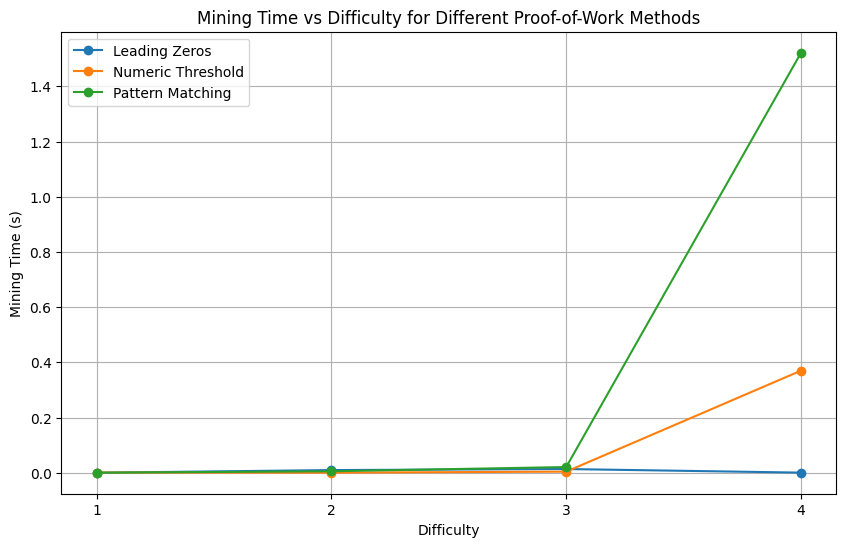

In [10]:
pow_types = ["leading_zeros", "numeric_threshold", "pattern_matching"]
difficulties = [1, 2, 3, 4] # Using the same difficulties as the previous example

mining_times_by_pow_type = {} # Dictionary to store mining times for each PoW type

for pow_type in pow_types:
    print(f"Testing Proof-of-Work type: {pow_type}")
    times_for_current_pow_type = []
    for d in difficulties:
        # Ensure difficulty is reasonable for each PoW type
        current_difficulty = d
        if pow_type == "numeric_threshold" and d > 6: # Numeric threshold becomes very hard quickly
            current_difficulty = 6
        elif pow_type == "pattern_matching" and d > 6: # Pattern matching can also be very hard
            current_difficulty = 6

        bc = Blockchain(difficulty=current_difficulty, reward=1, pow_type=pow_type) # New chain with specific PoW type
        bc.add_transaction("A", "B", 1) # Simple tx
        t, att = bc.mine_pending("MinerX") # Mine and time
        times_for_current_pow_type.append(t) # Record time
        print(f"  Difficulty {current_difficulty}: Mining time = {t:.4f} seconds (Attempts: {att})")
    mining_times_by_pow_type[pow_type] = times_for_current_pow_type

plt.figure(figsize=(10, 6))
for pow_type, times in mining_times_by_pow_type.items():
    plt.plot(difficulties[:len(times)], times, marker='o', label=f'{pow_type.replace("_", " ").title()}')

plt.xlabel('Difficulty')
plt.ylabel('Mining Time (s)')
plt.title('Mining Time vs Difficulty for Different Proof-of-Work Methods')
plt.xticks(difficulties)
plt.grid(True)
plt.legend()
plt.show()

#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.







